In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy as sc

In [16]:
df = sns.load_dataset('penguins')

df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## FASE 1:

Parte A:

In [17]:
def nan(x):
  count = 0
  for i in range(len(x)):
   if x.isna()[i] == True:
    count += 1
  return count

def dupli(x):
  count = 0
  for i in range(len(x)):
    df.duplicated()[i] == True


print(f"1. las filas y columnas del dataframe son respectivamente: {df.shape[0]} y {df.shape[1]} \n")


print("2.el tipo de cada variable es: \n",df.dtypes,"\n")

print("3. El numero de datos faltantes por columna son:")
for i in range(len(df.columns)):
  print(f"{df.columns[i]}: {nan(df[df.columns[i]])}")
print("\n")

print(f"4. El numero de filas duplicadas es: {df.duplicated().sum()} \n")

print(f"5.La cardinalidad para cada variable es:")
print(df.nunique())

1. las filas y columnas del dataframe son respectivamente: 344 y 7 

2.el tipo de cada variable es: 
 species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object 

3. El numero de datos faltantes por columna son:
species: 0
island: 0
bill_length_mm: 2
bill_depth_mm: 2
flipper_length_mm: 2
body_mass_g: 2
sex: 11


4. El numero de filas duplicadas es: 0 

5.La cardinalidad para cada variable es:
species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64


Parte B:

In [18]:
dfna = df.dropna()
num = dfna.select_dtypes(include = np.number)
cat = dfna.select_dtypes(include = "object")

#6.

def numerical(x):
  m = x.mean()
  med = x.median()
  a = x.std()
  q1, q2 = x.quantile(0.25), x.quantile(0.75)
  iqr = q2 - q1

  return m, med, a, iqr


media = []
mediana = []
alpha = []
iq = []
for i in range(len(num.columns)):
  media.append(numerical(num[num.columns[i]])[0])
  mediana.append(numerical(num[num.columns[i]])[1])
  alpha.append(numerical(num[num.columns[i]])[2])
  iq.append(numerical(num[num.columns[i]])[3])

nume = pd.DataFrame({'Variable': num.columns , 'Media': media , 'Mediana': mediana,
                     'Desviacion Estandar': alpha , 'Rango Intercuartilico': iq})

print(f"6. para las variables nuemricas tenemos los siguientes datos:")
nume

6. para las variables nuemricas tenemos los siguientes datos:


C:\Users\USER\AppData\Local\Temp\ipykernel_28412\2188760051.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = dfna.select_dtypes(include = "object")


,Variable,Media,Mediana,Desviacion Estandar,Rango Intercuartilico
0,bill_length_mm,43.992793,44.5,5.468668,9.1
1,bill_depth_mm,17.164865,17.3,1.969235,3.1
2,flipper_length_mm,200.966967,197.0,14.015765,23.0
3,body_mass_g,4207.057057,4050.0,805.215802,1225.0


In [19]:
#7.
print(f"7. para las variables categoricas:")

def variables(x):
  val = x.value_counts().index
  conteos = [float(i) for i in x.value_counts()]
  prob = [float(i) for i in x.value_counts(normalize = True)]
  return val,conteos,prob

cat_species = pd.DataFrame({'Variable': variables(cat["species"])[0] , 'Conteos': variables(cat["species"])[1], 'Probabilidad': variables(cat["species"])[2]})

cat_island = pd.DataFrame({'Variable': variables(cat["island"])[0], 'Conteos': variables(cat["island"])[1], 'Probabilidad': variables(cat["island"])[2]})

cat_sex = pd.DataFrame({'Variable': variables(cat["sex"])[0], 'Conteos': variables(cat["sex"])[1], 'Probabilidad': variables(cat["sex"])[2]})

print(cat_species, "\n")
print(cat_island, "\n")
print(cat_sex, "\n")


7. para las variables categoricas:
    Variable  Conteos  Probabilidad
0     Adelie    146.0      0.438438
1     Gentoo    119.0      0.357357
2  Chinstrap     68.0      0.204204 

    Variable  Conteos  Probabilidad
0     Biscoe    163.0      0.489489
1      Dream    123.0      0.369369
2  Torgersen     47.0      0.141141 

  Variable  Conteos  Probabilidad
0     Male    168.0      0.504505
1   Female    165.0      0.495495 



In [20]:
#8.
tabla1 = pd.crosstab([cat["species"]],cat["island"])
tabla2 = pd.crosstab([cat["species"]],cat["sex"])
tabla3 = pd.crosstab([cat["island"]],cat["sex"])

print(f"8. las tablas cruzadas son:")
print(tabla1,"\n")
print(tabla2,"\n")
print(tabla3,"\n")

8. las tablas cruzadas son:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0 

sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61 

sex        Female  Male
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23 



In [21]:
#9.
corr_Pearson = num.corr(method = "pearson")
corr_spearman = num.corr(method = "spearman")

corr_Pearson

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [22]:
corr_spearman

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.213859,0.669754,0.576480
bill_depth_mm,-0.213859,1.000000,-0.517317,-0.429283
flipper_length_mm,0.669754,-0.517317,1.000000,0.840390
body_mass_g,0.576480,-0.429283,0.840390,1.000000


Parte C:

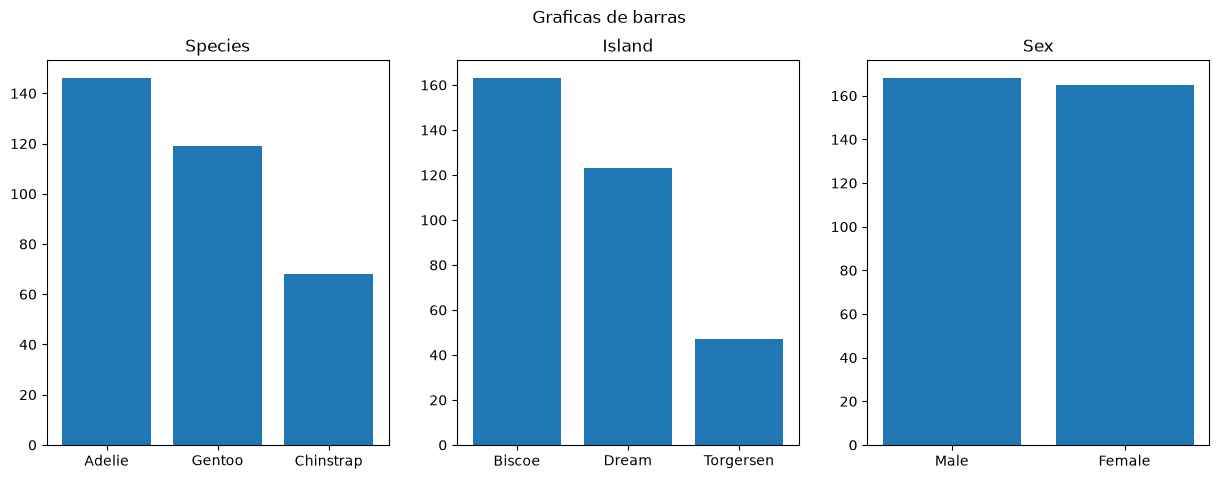

In [23]:
#10.
fig , (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (15,5))
fig.suptitle("Graficas de barras")
ax1.bar(cat_species["Variable"],cat_species["Conteos"])
ax1.set_title("Species")
ax2.bar(cat_island["Variable"],cat_island["Conteos"])
ax2.set_title("Island")
ax3.bar(cat_sex["Variable"],cat_sex["Conteos"])
ax3.set_title("Sex")
plt.show()

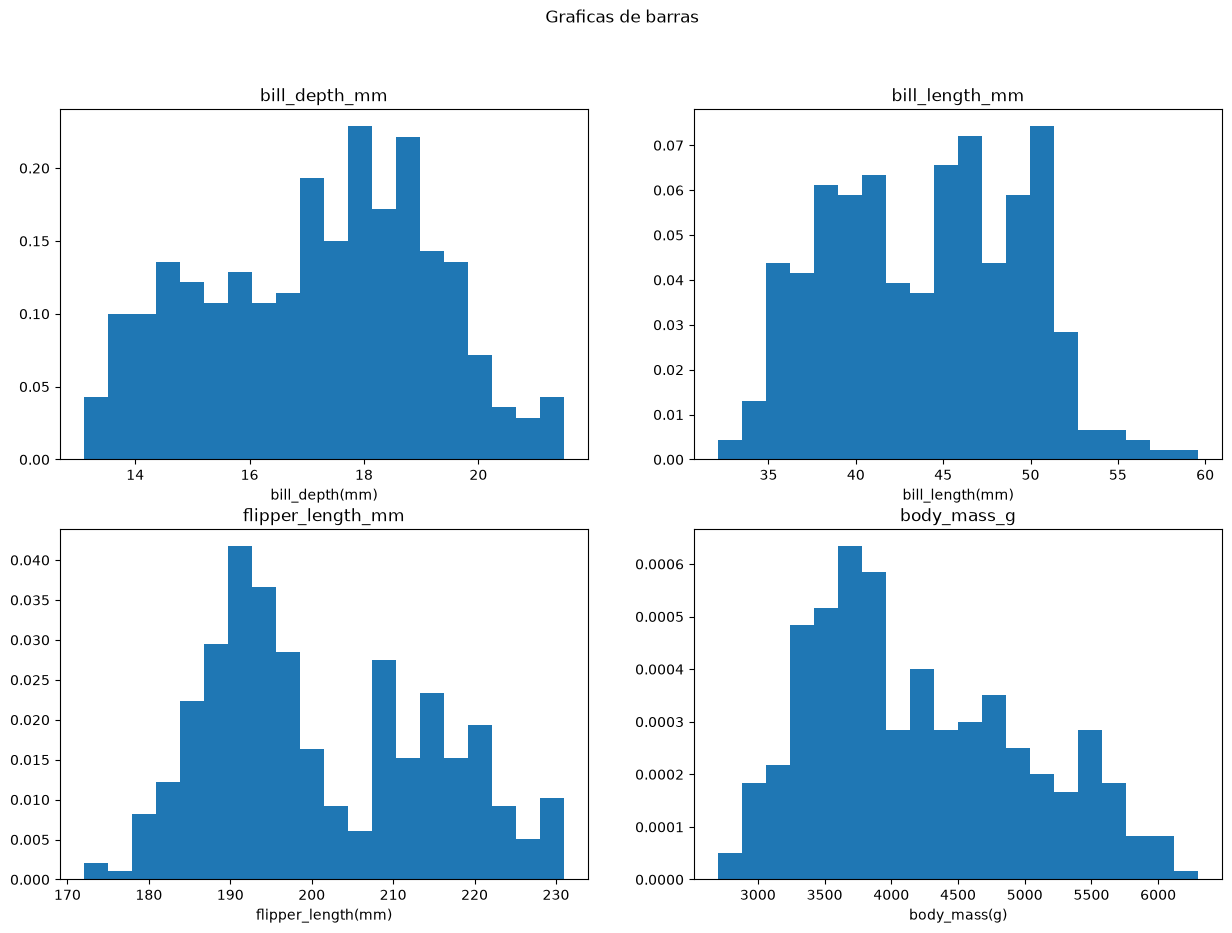

In [24]:
#11.

fig, axes = plt.subplots(2,2, figsize = (15,10))
fig.suptitle("Graficas de barras")

axes[0,0].hist(num['bill_depth_mm'], density = True, bins = 20)
axes[0,0].set_xlabel('bill_depth(mm)')
axes[0,0].set_title('bill_depth_mm')

axes[0,1].hist(num['bill_length_mm'], density = True, bins = 20)
axes[0,1].set_xlabel('bill_length(mm)')
axes[0,1].set_title('bill_length_mm')

axes[1,0].hist(num['flipper_length_mm'], density = True, bins = 20)
axes[1,0].set_xlabel('flipper_length(mm)')
axes[1,0].set_title('flipper_length_mm')

axes[1,1].hist(num['body_mass_g'], density = True, bins = 20)
axes[1,1].set_xlabel('body_mass(g)')
axes[1,1].set_title('body_mass_g')
plt.show()

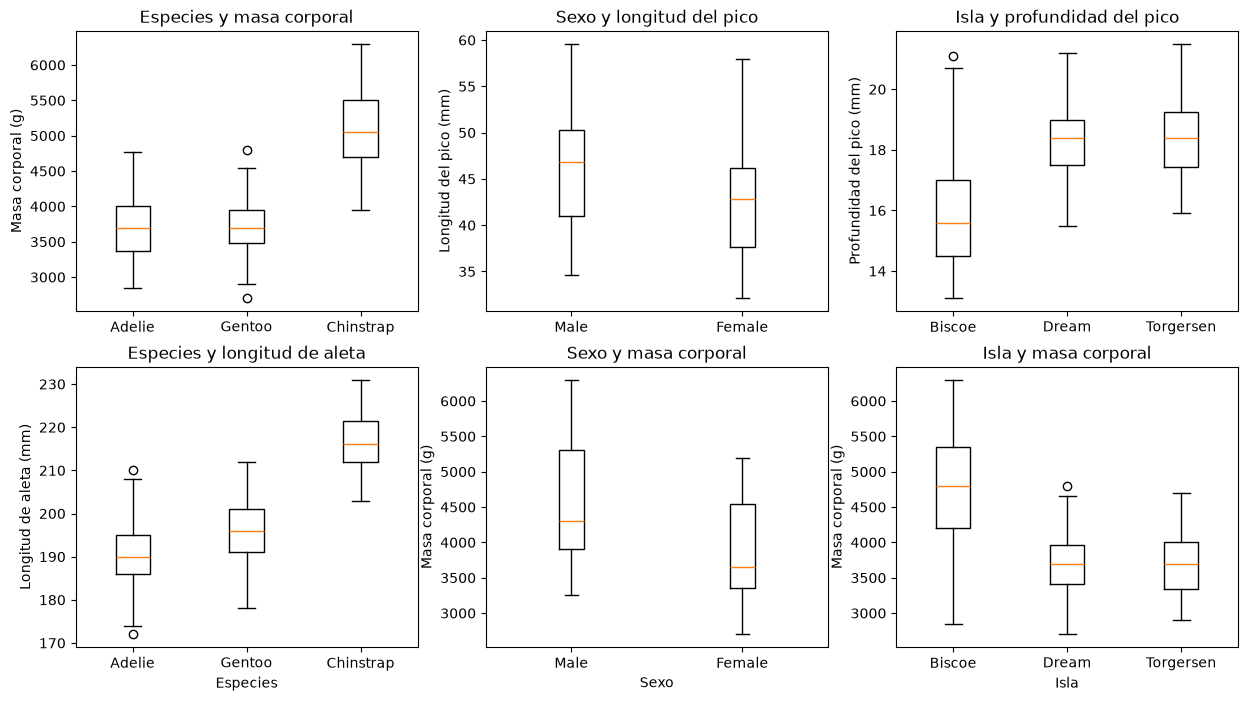

In [25]:
#12.
df1 = df.dropna()

##############################################

ade = df1.loc[df1["species"] == "Adelie"]
chin = df1.loc[df1["species"] == "Chinstrap"]
gen = df1.loc[df1["species"] == "Gentoo"]

male = df1.loc[df1["sex"] == "Male"]
female = df1.loc[df1["sex"] == "Female"]

bis = df1.loc[df1["island"] == "Biscoe"]
dream = df1.loc[df1["island"] == "Dream"]
torg = df1.loc[df1["island"] == "Torgersen"]

#especie y masa corporal
spec1 = [ade["body_mass_g"], chin["body_mass_g"], gen["body_mass_g"]]

#sexo y longitud del pico del pico

sex1 = [male["bill_length_mm"], female["bill_length_mm"]]

#isla y profundidad del pico

isla1 = [bis["bill_depth_mm"], dream["bill_depth_mm"], torg["bill_depth_mm"]]

#especie y flipper

spec2 = [ade["flipper_length_mm"], chin["flipper_length_mm"], gen["flipper_length_mm"]]

# sexo y masa corporal

sex2 = [male["body_mass_g"], female["body_mass_g"]]

#isla y masa corpor

isla2 = [bis["body_mass_g"], dream["body_mass_g"], torg["body_mass_g"]]

##############################################

fig, ax = plt.subplots(2,3, figsize = (15,8))

ax[0,0].boxplot(spec1, tick_labels = df1["species"].value_counts().index)
ax[0,0].set_ylabel("Masa corporal (g)")
ax[0,0].set_title("Especies y masa corporal")

ax[0,1].boxplot(sex1, tick_labels = df1["sex"].value_counts().index)
ax[0,1].set_ylabel("Longitud del pico (mm)")
ax[0,1].set_title("Sexo y longitud del pico")

ax[0,2].boxplot(isla1, tick_labels = df1["island"].value_counts().index)
ax[0,2].set_ylabel("Profundidad del pico (mm)")
ax[0,2].set_title("Isla y profundidad del pico")

ax[1,0].boxplot(spec2, tick_labels = df1["species"].value_counts().index)
ax[1,0].set_xlabel("Especies")
ax[1,0].set_ylabel("Longitud de aleta (mm)")
ax[1,0].set_title("Especies y longitud de aleta")

ax[1,1].boxplot(sex2, tick_labels = df1["sex"].value_counts().index)
ax[1,1].set_xlabel("Sexo")
ax[1,1].set_ylabel("Masa corporal (g)")
ax[1,1].set_title("Sexo y masa corporal")

ax[1,2].boxplot(isla2, tick_labels = df1["island"].value_counts().index)
ax[1,2].set_xlabel("Isla")
ax[1,2].set_ylabel("Masa corporal (g)")
ax[1,2].set_title("Isla y masa corporal")
plt.show()

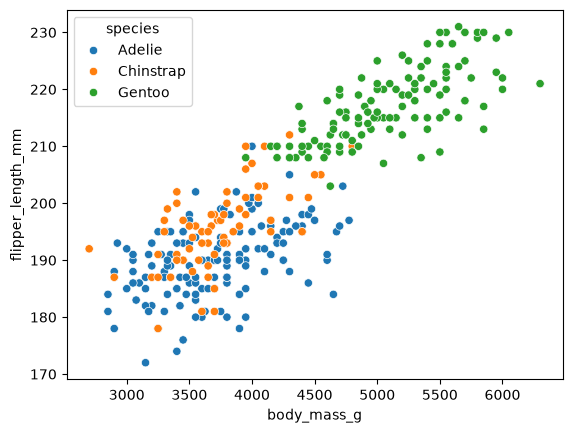

In [26]:
#13.
sns.scatterplot(data = df1, x = "body_mass_g", y = "flipper_length_mm", hue = df1["species"])
plt.show()

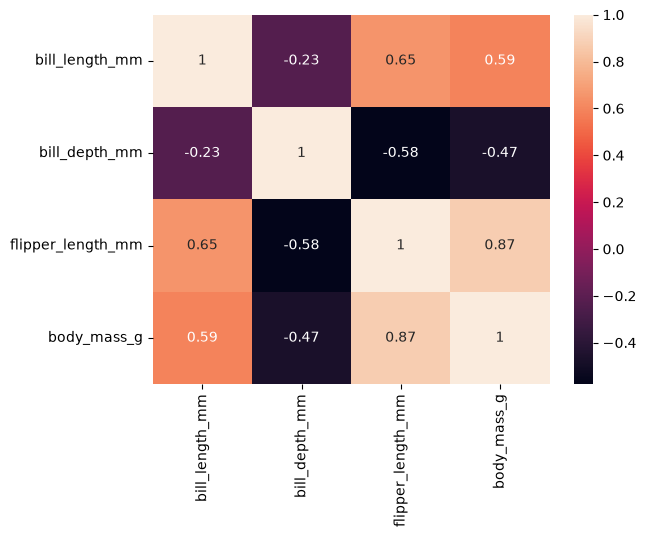

In [27]:
#14.
sns.heatmap(corr_Pearson, annot = True)
plt.show()

Parte D:

## Hipotesis
#15.

1. body_mass_g difiere por species
2. bill_length_mm se asocia por sex
3. island se asocia por species


Parte E:

In [28]:
#Pruebas estadisticas

#16., 17. y 18. se hacen pruebas de hipotesis para ver si las variables categoricas y numericas se asocian o difieren entre si

#body_mass_g difiere por species
from scipy.stats import kruskal


data = dfna[['body_mass_g', 'species']]


grupos = [grupo['body_mass_g'].values for _, grupo in data.groupby('species')]


stat, p_value = kruskal(*grupos)

print("Para este caso se usa la prueba de Kruskal-Wallis")
print(f"Estadístico H: {stat:.4f}") 
print(f"Valor p: {p_value:.4f}")
print("segun el pvalor, la variable body_mass_g difiere por species \n")

#bill_length_mm se asocia por sex

from scipy import stats

categorica = dfna['sex'].map({'Male': 0, 'Female': 1}).values
numerica = dfna['bill_length_mm'].values

coeficiente, p_valor = stats.pointbiserialr(categorica, numerica)

print("Para este caso se usa el coeficiente de correlacion punto biserial")
print(f"Coeficiente Punto Biserial: {coeficiente}")
print(f"P-valor: {p_valor}")
print("segun el pvalor, la variable bill_length_mm no se asocia con sex \n")

#island se asocia por species

from scipy.stats import chi2_contingency

tabla = pd.crosstab(dfna['species'], dfna['island'])

chi2, p_valor, dof, esperados = chi2_contingency(tabla)

print("Para este caso se usa la prueba de Chi-Cuadrado")
print(f"Estadístico Chi2: {chi2}")
print(f"P-valor: {p_valor}")
print("segun el pvalor, la variable island se asocia con species \n")


Para este caso se usa la prueba de Kruskal-Wallis
Estadístico H: 212.0851
Valor p: 0.0000
segun el pvalor, la variable body_mass_g difiere por species 

Para este caso se usa el coeficiente de correlacion punto biserial
Coeficiente Punto Biserial: -0.3440777822374857
P-valor: 1.0942555387200133e-10
segun el pvalor, la variable bill_length_mm no se asocia con sex 

Para este caso se usa la prueba de Chi-Cuadrado
Estadístico Chi2: 284.5900126880923
P-valor: 2.2818915409873682e-60
segun el pvalor, la variable island se asocia con species 



## Parte F:

Conclusiones: 

A). 
- Los datos numericos por si solo no presentan la forma de una distribucion normal logrado ver en los histogramas realizados
- En todas las especies de pinguinos se logra ver una cantidad similar entre machos y hembras,logrado ver en los graficos de barra

B).
- Se pued ever un patron entre la masa corporal de los pinguinos y su especie mostrado en los graficos de caja.
- Se observa un patron en la relacion entre el tamaño de la aleta y la masa corporal de los pinguinos que tiene una relacion clara con la especie del pinguino.

C). 
- ¿Los histogramas hechos de los datos corporales de los pinguinos pdrian cambiar su forma si se añaden los datos faltantes del dataframe?
- ¿Estos histogramas podrian cambiar su forma sise toma en cuenta la especie o el sexo del pinguino?
- ¿Que otras variables podrian asociarse a los datos tomados en el dataframe?

